# Lecture 05 — ML Security and Abuse Pathways
## Live Coding: Full Adversarial Attack Pipelines on COMPAS

**Instructor:** Dr. Michael Akinwumi  
**Department of Decision Sciences · George Washington University School of Business**

---

This notebook continues directly from `Lecture-04-generalization.ipynb`.  
Dataset: [ProPublica COMPAS Analysis](https://github.com/propublica/compas-analysis)

### Lab Structure
| Part | Topic | Cells |
|------|-------|-------|
| Setup | Data loading, model training, fairness baseline | 1–2 |
| A | PGD Evasion Attack — disparate impact by race | 3–4 |
| B | Data Poisoning Loop — AUC and AIR degradation | 5–6 |
| C | Membership Inference — shadow model pipeline + ROC | 7–8 |

**Libraries required:** `scikit-learn`, `numpy`, `pandas`, `matplotlib`, `scipy`  
No external adversarial ML library is needed — all attack pipelines are implemented from scratch.

**NIST Reference:** Vassilev et al. (2024). *Adversarial Machine Learning: A Taxonomy and Terminology of Attacks and Mitigations.* NIST AI 100-2e2023. https://doi.org/10.6028/NIST.AI.100-2e2023

---
## Setup · Cell 1: Imports, Data Loading, and Model Training

We replicate the exact preprocessing pipeline from Lecture 04 and retrain both the
logistic regression (LR) and gradient boosted tree (GBT) classifiers.

**Threat modeling reminder (NIST AI 100-2, §2.1):**  
Before testing any attack, specify: *Who is the adversary? What do they know?
What can they control? What is their goal?*

In [1]:
# ── Cell 1: Imports, Data Loading, Model Training ─────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# ── Load COMPAS dataset (ProPublica) ──────────────────────────────────────────
URL = (
    "https://raw.githubusercontent.com/propublica/compas-analysis"
    "/master/compas-scores-two-years.csv"
)
df = pd.read_csv(URL)
print(f"Raw dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")

# ── Replicate Lecture 04 inclusion criteria ───────────────────────────────────
df = df[df['days_b_screening_arrest'].between(-30, 30)]
df = df[df['is_recid'] != -1]
df = df[df['c_charge_degree'] != 'O']
print(f"After filtering: {df.shape[0]:,} rows")

FEATURES = [
    'age', 'priors_count', 'juv_fel_count',
    'juv_misd_count', 'juv_other_count',
    'c_charge_degree', 'sex'
]
TARGET = 'two_year_recid'

df_m = df[FEATURES + [TARGET, 'race']].dropna()
df_m = pd.get_dummies(df_m, columns=['c_charge_degree', 'sex'], drop_first=True)

X    = df_m.drop(columns=[TARGET, 'race']).astype(float)
y    = df_m[TARGET].values
race = df_m['race'].values

print(f"\nFeatures used: {list(X.columns)}")
print(f"Class balance: {y.mean():.1%} recidivism rate")

# ── Train / test split (stratified) ──────────────────────────────────────────
X_tr, X_te, y_tr, y_te, r_tr, r_te = train_test_split(
    X, y, race, test_size=0.3, random_state=42, stratify=y
)

sc    = StandardScaler()
Xs_tr = sc.fit_transform(X_tr)
Xs_te = sc.transform(X_te)

# ── Train models ──────────────────────────────────────────────────────────────
lr  = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr)
gbt = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, random_state=42
).fit(Xs_tr, y_tr)

print(f"\nLR  Test AUC: {roc_auc_score(y_te, lr.predict_proba(Xs_te)[:,1]):.3f}")
print(f"GBT Test AUC: {roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:,1]):.3f}")
print(f"LR  Train AUC: {roc_auc_score(y_tr, lr.predict_proba(Xs_tr)[:,1]):.3f}")
print(f"GBT Train AUC: {roc_auc_score(y_tr, gbt.predict_proba(Xs_tr)[:,1]):.3f}")

Raw dataset: 7,214 rows, 53 columns
After filtering: 6,172 rows

Features used: ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'c_charge_degree_M', 'sex_Male']
Class balance: 45.5% recidivism rate

LR  Test AUC: 0.735
GBT Test AUC: 0.718
LR  Train AUC: 0.727
GBT Train AUC: 0.798


---
## Setup · Cell 2: Clean-Model Fairness Baseline

Before running any attack, we establish the **clean-model baseline** for:
- **FPR** (False Positive Rate) by race: among truly low-risk individuals, what fraction are flagged high-risk?
- **AIR** (Adverse Impact Ratio): FPR of protected group / FPR of reference group

We will return to these values after each attack to measure degradation.

> **Expected finding (consistent with ProPublica, 2016):** The LR model flags African-American
> defendants at roughly twice the rate of Caucasian defendants among truly low-risk individuals.

In [2]:
# ── Cell 2: Clean-Model Fairness Baseline ─────────────────────────────────────

THR = 0.5  # classification threshold

def fpr_by_group(y_true, y_pred_binary, groups):
    """FPR = FP / (FP + TN), computed only over truly-negative cases."""
    mask = (y_true == 0)
    return (
        pd.DataFrame({'pred': y_pred_binary[mask], 'group': groups[mask]})
          .groupby('group')['pred']
          .mean()
    )

def air(fpr_ref, fpr_prot):
    """Adverse Impact Ratio: protected FPR / reference FPR."""
    return fpr_prot / fpr_ref if (fpr_ref is not None and fpr_ref > 0) else np.nan

# ── Compute baseline predictions ──────────────────────────────────────────────
pred_lr_clean  = (lr.predict_proba(Xs_te)[:,1]  >= THR).astype(int)
pred_gbt_clean = (gbt.predict_proba(Xs_te)[:,1] >= THR).astype(int)

print("=" * 60)
print("CLEAN MODEL BASELINE — Before Any Attack")
print("=" * 60)

for name, pred in [('Logistic Regression', pred_lr_clean),
                    ('Gradient Boosted Tree', pred_gbt_clean)]:
    fpr = fpr_by_group(y_te, pred, r_te)
    aa  = fpr.get('African-American', np.nan)
    ca  = fpr.get('Caucasian',        np.nan)
    print(f"\n{name}")
    print(f"  FPR African-American : {aa:.3f}")
    print(f"  FPR Caucasian        : {ca:.3f}")
    print(f"  AIR (AA / CA)        : {air(ca, aa):.3f}")

# Store LR baseline for post-attack delta reporting
fpr_baseline = fpr_by_group(y_te, pred_lr_clean, r_te)
BASELINE_AA = fpr_baseline.get('African-American')
BASELINE_CA = fpr_baseline.get('Caucasian')
BASELINE_AIR = air(BASELINE_CA, BASELINE_AA)

print(f"\n→ Baseline LR AIR stored: {BASELINE_AIR:.3f}")
print("  We will compare all attack outcomes against these values.")

CLEAN MODEL BASELINE — Before Any Attack

Logistic Regression
  FPR African-American : 0.281
  FPR Caucasian        : 0.143
  AIR (AA / CA)        : 1.961

Gradient Boosted Tree
  FPR African-American : 0.317
  FPR Caucasian        : 0.178
  AIR (AA / CA)        : 1.782

→ Baseline LR AIR stored: 1.961
  We will compare all attack outcomes against these values.


---
## Part A · Cell 3: PGD Evasion Attack

**Attack class (NIST AI 100-2, §2.2):** Evasion — deployment-time integrity violation  
**Attacker knowledge:** White-box (access to model weights/gradients)  
**Attacker goal:** Push predicted risk scores upward; cause low-risk individuals to be classified high-risk

### Algorithm: Projected Gradient Descent (Madry et al., 2018)

$$\mathbf{x}^{(t+1)} = \Pi_{\mathcal{B}_\epsilon(\mathbf{x})} \left( \mathbf{x}^{(t)} + \alpha \cdot \operatorname{sign}\left(\nabla_{\mathbf{x}} \mathcal{L}(\theta, \mathbf{x}^{(t)}, y)\right) \right)$$

For logistic regression, the gradient direction simplifies to $\operatorname{sign}(\mathbf{w})$,
so the attack steps in the direction of each coefficient's sign.

**$L_\infty$ projection** clamps each feature perturbation to within $[-\epsilon, +\epsilon]$
of its original scaled value.

In [3]:
# ── Cell 3: PGD Evasion Attack — The Loop ─────────────────────────────────────

def pgd_tabular(model, X_scaled, epsilon=1.0, alpha=0.05, n_iter=40):
    """
    PGD evasion attack on tabular data for logistic regression.

    Goal: untargeted attack — push predicted P(high-risk) higher.

    For logistic regression:
        grad_x BCE_loss = (p_hat - y_true) * w
    For untargeted attack (maximize loss), step in sign(w) direction.

    Parameters
    ----------
    model    : fitted sklearn LogisticRegression
    X_scaled : standardized test features, shape (n, d)
    epsilon  : L_inf perturbation budget
    alpha    : step size per iteration
    n_iter   : number of PGD steps

    Returns
    -------
    X_adv : adversarially perturbed inputs, shape (n, d)
    """
    coef  = model.coef_[0]               # shape (d,) — LR coefficients
    X_adv = X_scaled.copy()

    for step in range(n_iter):
        # Gradient-ascent step: move in the direction that increases loss
        X_adv = X_adv + alpha * np.sign(coef)[np.newaxis, :]

        # L_inf projection: clip back into the epsilon-ball around X_scaled
        X_adv = np.clip(X_adv, X_scaled - epsilon, X_scaled + epsilon)

    return X_adv


# ── Sweep epsilon to build an attack-strength curve ───────────────────────────
epsilons    = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
pgd_records = []

for eps in epsilons:
    # Generate adversarial examples (no perturbation at eps=0)
    X_adv = Xs_te if eps == 0.0 else pgd_tabular(
        lr, Xs_te, epsilon=eps, alpha=0.05, n_iter=40
    )

    pred_adv = (lr.predict_proba(X_adv)[:,1] >= THR).astype(int)
    fpr_adv  = fpr_by_group(y_te, pred_adv, r_te)

    aa = fpr_adv.get('African-American', np.nan)
    ca = fpr_adv.get('Caucasian',        np.nan)

    pgd_records.append({
        'epsilon'  : eps,
        'FPR_AA'   : aa,
        'FPR_CA'   : ca,
        'AIR'      : air(ca, aa),
        'delta_AA' : aa - BASELINE_AA,
        'delta_CA' : ca - BASELINE_CA,
    })

df_pgd = pd.DataFrame(pgd_records)
print(df_pgd.round(3).to_string(index=False))

 epsilon  FPR_AA  FPR_CA   AIR  delta_AA  delta_CA
    0.00   0.281   0.143 1.961     0.000     0.000
    0.25   0.569   0.370 1.535     0.288     0.227
    0.50   0.791   0.560 1.411     0.510     0.417
    0.75   0.906   0.758 1.195     0.625     0.615
    1.00   0.978   0.884 1.106     0.697     0.741
    1.50   1.000   0.993 1.007     0.719     0.849
    2.00   1.000   1.000 1.000     0.719     0.857


### Part A · Cell 4: Visualize PGD Disparate Impact

**Discussion questions:**
1. Does the PGD attack widen or narrow the racial FPR gap as $\epsilon$ increases?
2. At what $\epsilon$ does the AIR fall below the 4/5ths rule threshold (0.80)?
3. Are the two groups equally sensitive to the same attack strength?
4. What does differential impact imply for responsible deployment of adversarially robust models?

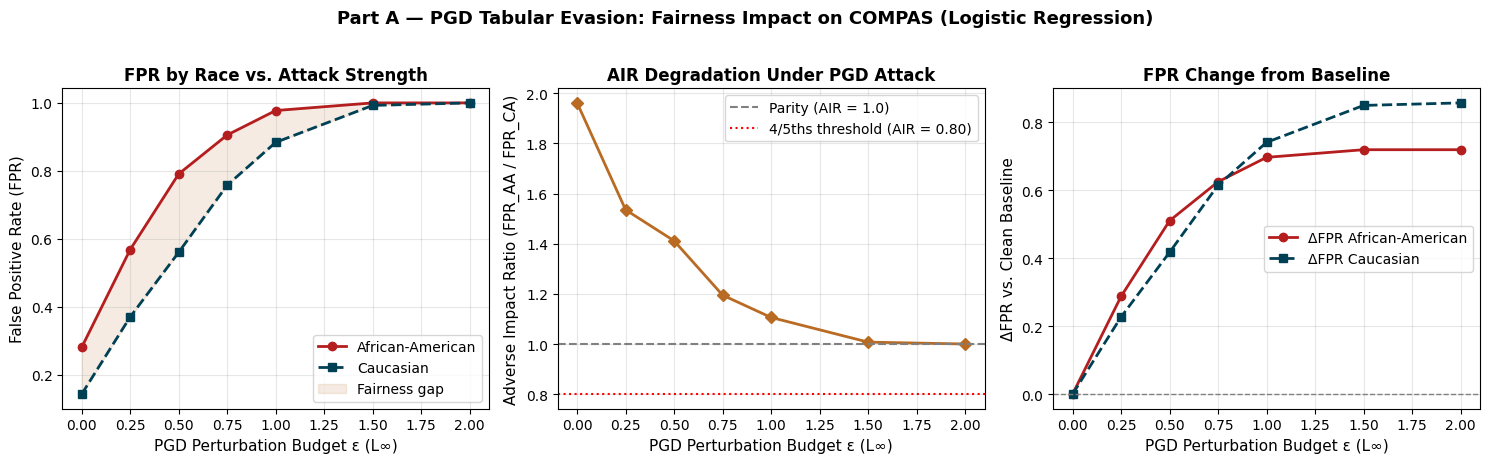

AIR does not fall below 0.80 within the tested epsilon range.


In [4]:
# ── Cell 4: Visualize PGD Evasion — Disparate Impact ──────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ── Panel 1: FPR by race ──────────────────────────────────────────────────────
ax = axes[0]
ax.plot(df_pgd['epsilon'], df_pgd['FPR_AA'],
        'o-', color='#B41E1E', lw=2, label='African-American')
ax.plot(df_pgd['epsilon'], df_pgd['FPR_CA'],
        's--', color='#004055', lw=2, label='Caucasian')
ax.fill_between(df_pgd['epsilon'], df_pgd['FPR_AA'], df_pgd['FPR_CA'],
                alpha=0.13, color='#B96B23', label='Fairness gap')
ax.set_xlabel('PGD Perturbation Budget ε (L∞)', fontsize=11)
ax.set_ylabel('False Positive Rate (FPR)', fontsize=11)
ax.set_title('FPR by Race vs. Attack Strength', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# ── Panel 2: AIR ──────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(df_pgd['epsilon'], df_pgd['AIR'],
        'D-', color='#B96B23', lw=2)
ax.axhline(1.0, color='gray', lw=1.5, ls='--', label='Parity (AIR = 1.0)')
ax.axhline(0.8, color='red',  lw=1.5, ls=':',  label='4/5ths threshold (AIR = 0.80)')
ax.set_xlabel('PGD Perturbation Budget ε (L∞)', fontsize=11)
ax.set_ylabel('Adverse Impact Ratio (FPR_AA / FPR_CA)', fontsize=11)
ax.set_title('AIR Degradation Under PGD Attack', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# ── Panel 3: Absolute FPR change vs. baseline ─────────────────────────────────
ax = axes[2]
ax.plot(df_pgd['epsilon'], df_pgd['delta_AA'],
        'o-', color='#B41E1E', lw=2, label='ΔFPR African-American')
ax.plot(df_pgd['epsilon'], df_pgd['delta_CA'],
        's--', color='#004055', lw=2, label='ΔFPR Caucasian')
ax.axhline(0, color='gray', lw=1, ls='--')
ax.set_xlabel('PGD Perturbation Budget ε (L∞)', fontsize=11)
ax.set_ylabel('ΔFPR vs. Clean Baseline', fontsize=11)
ax.set_title('FPR Change from Baseline', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle(
    'Part A — PGD Tabular Evasion: Fairness Impact on COMPAS (Logistic Regression)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

# ── Identify crossover point ───────────────────────────────────────────────────
cross = df_pgd[df_pgd['AIR'] < 0.8].head(1)
if len(cross):
    print(f"AIR crosses 0.80 at ε = {cross.iloc[0]['epsilon']:.2f}")
else:
    print("AIR does not fall below 0.80 within the tested epsilon range.")

---
## Part B · Cell 5: Data Poisoning — Label-Flip Attack Loop

**Attack class (NIST AI 100-2, §2.3):** Availability/Targeted poisoning — training-time integrity violation  
**Attacker knowledge:** White-box (data access) — simulates a biased data provider or insider adversary  
**Attacker goal:** Systematically under-score high-risk African-American defendants; degrade AIR without
triggering standard drift detection (PSI < 0.10)

### Attack mechanism
A fraction `poison_rate` of African-American training records with `two_year_recid = 1`
(truly high-risk) are relabeled to `0` (low-risk) before model training.
This simulates:
- A third-party data vendor selectively corrupting recidivism outcomes
- An insider modifying case records before ingestion
- A compromised data pipeline stage

> **Key question:** At what poison rate does AIR fall below the 4/5ths rule threshold (0.80)
> while AUC declines by ≤ 2 percentage points — i.e., the attack is "invisible" to AUC monitoring?

In [5]:
# ── Cell 5: Data Poisoning — Label-Flip Attack ────────────────────────────────

def poison_label_flip(
    y_train, race_train,
    poison_rate=0.05,
    target_race='African-American',
    seed=0
):
    """
    Label-flip poisoning attack.

    Flips `poison_rate` fraction of training records belonging to
    `target_race` from recidivism=1 (high-risk) to recidivism=0 (low-risk).

    Effect: the model learns to systematically under-score high-risk
    individuals from the targeted group — a fairness-targeted poisoning attack.

    Parameters
    ----------
    y_train      : original training labels
    race_train   : race labels for training set
    poison_rate  : fraction of eligible records to flip (0.0 to 1.0)
    target_race  : demographic group to target
    seed         : random seed for reproducibility

    Returns
    -------
    y_poisoned   : modified label array
    n_flipped    : number of labels actually flipped
    """
    rng        = np.random.default_rng(seed)
    y_poisoned = y_train.copy()

    # Eligible candidates: target race, truly high-risk (label=1)
    candidates = np.where(
        (race_train == target_race) & (y_train == 1)
    )[0]

    n_flip = int(len(candidates) * poison_rate)
    if n_flip > 0:
        flip_idx = rng.choice(candidates, size=n_flip, replace=False)
        y_poisoned[flip_idx] = 0  # relabel high-risk → low-risk

    return y_poisoned, n_flip


# ── Sweep poison rates ────────────────────────────────────────────────────────
poison_rates   = [0.00, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]
poison_records = []

baseline_auc = roc_auc_score(y_te, lr.predict_proba(Xs_te)[:,1])

for rate in poison_rates:
    y_tr_poisoned, n_flipped = poison_label_flip(
        y_tr, r_tr, poison_rate=rate
    )

    # Retrain LR on poisoned data (same features, same scaler)
    lr_p = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr_poisoned)

    pred_p = (lr_p.predict_proba(Xs_te)[:,1] >= THR).astype(int)
    auc_p  = roc_auc_score(y_te, lr_p.predict_proba(Xs_te)[:,1])
    fpr_p  = fpr_by_group(y_te, pred_p, r_te)

    aa = fpr_p.get('African-American', np.nan)
    ca = fpr_p.get('Caucasian',        np.nan)

    poison_records.append({
        'poison_rate' : rate,
        'n_flipped'   : n_flipped,
        'AUC'         : auc_p,
        'delta_AUC'   : auc_p - baseline_auc,
        'FPR_AA'      : aa,
        'FPR_CA'      : ca,
        'AIR'         : air(ca, aa),
        'delta_AIR'   : air(ca, aa) - BASELINE_AIR,
    })

df_poison = pd.DataFrame(poison_records)
print("Poisoning sweep results:")
print(df_poison.round(3).to_string(index=False))

# ── Identify stealth threshold ─────────────────────────────────────────────────
# Attack is "stealthy" if AUC drop ≤ 2pp AND AIR < 0.80
stealth = df_poison[(df_poison['AIR'] < 0.80) & (df_poison['delta_AUC'] >= -0.02)]
if len(stealth):
    r = stealth.iloc[0]
    print(f"\n★ Stealth threshold: poison_rate = {r['poison_rate']:.0%}")
    print(f"  Flipped labels: {int(r['n_flipped'])}")
    print(f"  AUC: {r['AUC']:.3f} (Δ = {r['delta_AUC']:+.3f})")
    print(f"  AIR: {r['AIR']:.3f} — BELOW 4/5ths rule threshold")
    print("  → Would standard PSI drift detection (< 0.10) flag this?")
else:
    print("\nNo stealth threshold found in tested range.")

Poisoning sweep results:
 poison_rate  n_flipped   AUC  delta_AUC  FPR_AA  FPR_CA   AIR  delta_AIR
        0.00          0 0.735      0.000   0.281   0.143 1.961      0.000
        0.02         23 0.733     -0.002   0.270   0.136 1.986      0.024
        0.05         57 0.734     -0.001   0.240   0.123 1.948     -0.014
        0.08         92 0.732     -0.002   0.213   0.116 1.840     -0.122
        0.10        115 0.735      0.000   0.196   0.101 1.931     -0.030
        0.15        172 0.732     -0.003   0.153   0.072 2.134      0.173
        0.20        230 0.732     -0.002   0.130   0.054 2.399      0.438
        0.25        287 0.730     -0.004   0.112   0.042 2.677      0.715
        0.30        345 0.731     -0.003   0.097   0.032 3.010      1.049

No stealth threshold found in tested range.


### Part B · Cell 6: Poisoning Degradation Curves

**Discussion questions:**
1. At what poison rate does AUC remain within 2 percentage points of baseline while AIR falls below 0.80?
2. Would a PSI-based drift monitor (threshold < 0.10 on each feature) detect this attack?
3. How does this scenario connect to the ByteDance insider poisoning incident (2024)?
4. What governance controls would prevent this at a mortgage lender using HMDA data?

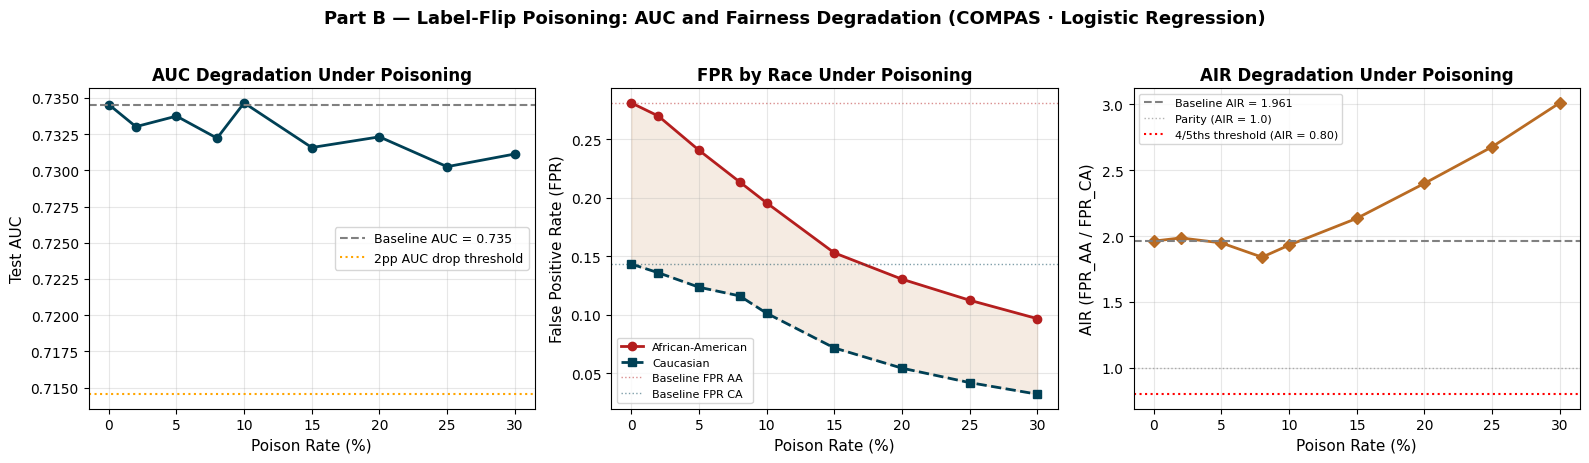

In [6]:
# ── Cell 6: Poisoning Degradation Curves ──────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
x_pct = df_poison['poison_rate'] * 100

# ── Panel 1: AUC degradation ──────────────────────────────────────────────────
ax = axes[0]
ax.plot(x_pct, df_poison['AUC'], 'o-', color='#004055', lw=2)
ax.axhline(baseline_auc,         color='gray', ls='--', lw=1.5,
           label=f'Baseline AUC = {baseline_auc:.3f}')
ax.axhline(baseline_auc - 0.02,  color='orange', ls=':', lw=1.5,
           label='2pp AUC drop threshold')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('Test AUC', fontsize=11)
ax.set_title('AUC Degradation Under Poisoning', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Panel 2: FPR by race ──────────────────────────────────────────────────────
ax = axes[1]
ax.plot(x_pct, df_poison['FPR_AA'],
        'o-', color='#B41E1E', lw=2, label='African-American')
ax.plot(x_pct, df_poison['FPR_CA'],
        's--', color='#004055', lw=2, label='Caucasian')
ax.fill_between(x_pct, df_poison['FPR_AA'], df_poison['FPR_CA'],
                alpha=0.13, color='#B96B23')
ax.axhline(BASELINE_AA, color='#B41E1E', ls=':', lw=1, alpha=0.5,
           label='Baseline FPR AA')
ax.axhline(BASELINE_CA, color='#004055', ls=':', lw=1, alpha=0.5,
           label='Baseline FPR CA')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('False Positive Rate (FPR)', fontsize=11)
ax.set_title('FPR by Race Under Poisoning', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Panel 3: AIR ──────────────────────────────────────────────────────────────
ax = axes[2]
ax.plot(x_pct, df_poison['AIR'], 'D-', color='#B96B23', lw=2)
ax.axhline(BASELINE_AIR, color='gray',  ls='--', lw=1.5,
           label=f'Baseline AIR = {BASELINE_AIR:.3f}')
ax.axhline(1.0,           color='gray',  ls=':',  lw=1.0, alpha=0.6,
           label='Parity (AIR = 1.0)')
ax.axhline(0.8,           color='red',   ls=':',  lw=1.5,
           label='4/5ths threshold (AIR = 0.80)')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('AIR (FPR_AA / FPR_CA)', fontsize=11)
ax.set_title('AIR Degradation Under Poisoning', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(
    'Part B — Label-Flip Poisoning: AUC and Fairness Degradation (COMPAS · Logistic Regression)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

---
## Part C · Cell 7: Membership Inference — Shadow Model Pipeline

**Attack class (NIST AI 100-2, §2.4.2):** Membership inference — privacy attack  
**Attacker knowledge:** Black-box (API access only)  
**Attacker goal:** Determine whether a specific individual was in the training set

### Algorithm: Shokri et al. (2017) Shadow Model Attack

1. Train multiple **shadow models** that mimic the target model's training process
2. For each shadow model, we know which inputs were training members vs. non-members
3. Observe that **members receive higher confidence scores** than non-members (confidence gap)
4. Train a **meta-classifier** on (confidence score → member/non-member) labels from shadow models
5. Apply the meta-classifier to the **target model's** confidence scores

> **Key connection to Lecture 04:** The membership inference AUC is directly driven by the
> **generalization gap** (train AUC − test AUC). An overfit model leaks more about its training data.
> Overfitting is not only a robustness problem — it is a **privacy problem**.

In [7]:
# ── Cell 7: Membership Inference — Shadow Model Pipeline ──────────────────────

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedShuffleSplit

N_SHADOW = 10  # number of shadow models

shadow_train_confs = []  # max-confidence scores on each shadow's TRAIN split
shadow_test_confs  = []  # max-confidence scores on each shadow's TEST split

# Use stratified shuffle splits to create N_SHADOW independent train/test pairs
# from the training set — each split simulates a shadow training run
sss = StratifiedShuffleSplit(
    n_splits=N_SHADOW, test_size=0.5, random_state=0
)

print(f"Training {N_SHADOW} shadow models...")
for i, (tr_idx, te_idx) in enumerate(sss.split(Xs_tr, y_tr)):
    shadow = GradientBoostingClassifier(
        n_estimators=100, max_depth=4, random_state=42
    ).fit(Xs_tr[tr_idx], y_tr[tr_idx])

    # Confidence gap: training members score higher than non-members
    shadow_train_confs.append(
        shadow.predict_proba(Xs_tr[tr_idx]).max(axis=1)  # members
    )
    shadow_test_confs.append(
        shadow.predict_proba(Xs_tr[te_idx]).max(axis=1)  # non-members
    )
    if (i + 1) % 5 == 0:
        print(f"  Shadow model {i+1}/{N_SHADOW} trained")

# ── Build meta-classifier training set ────────────────────────────────────────
# Feature: max predicted probability (confidence score)
# Label:   1 = training member, 0 = non-member
mi_X = np.concatenate(
    shadow_train_confs + shadow_test_confs
).reshape(-1, 1)

mi_y = np.concatenate(
    [np.ones(len(c))  for c in shadow_train_confs] +
    [np.zeros(len(c)) for c in shadow_test_confs]
)

meta_clf = DecisionTreeClassifier(max_depth=6).fit(mi_X, mi_y)

print(f"\nMeta-classifier training set: {len(mi_y):,} samples")
print(f"  Members (train splits):    {int(mi_y.sum()):,}")
print(f"  Non-members (test splits): {int((mi_y == 0).sum()):,}")
print("\nMeta-classifier trained. Proceeding to attack the target model...")

Training 10 shadow models...
  Shadow model 5/10 trained
  Shadow model 10/10 trained

Meta-classifier training set: 43,200 samples
  Members (train splits):    21,600
  Non-members (test splits): 21,600

Meta-classifier trained. Proceeding to attack the target model...


### Part C · Cell 8: Membership Inference — ROC Curve and Interpretation

**Interpreting the MI AUC:**
- **0.50** = Random guessing — no privacy leakage detectable
- **0.55–0.65** = Weak leakage — model is somewhat overfit
- **0.65–0.75** = Moderate leakage — meaningful privacy risk
- **> 0.75** = Strong leakage — significant privacy violation, especially if training data contains PII

**Discussion questions:**
1. Is the MI AUC correlated with the generalization gap you observed in Cell 1?
2. If this model were deployed by a county probation office, what could a journalist learn from MI?
3. Would adding differential privacy (ε = 1.0) reduce the MI AUC? At what cost to AIR?
4. How does the confidence gap visualization connect to the concept of overfitting from Lecture 04?

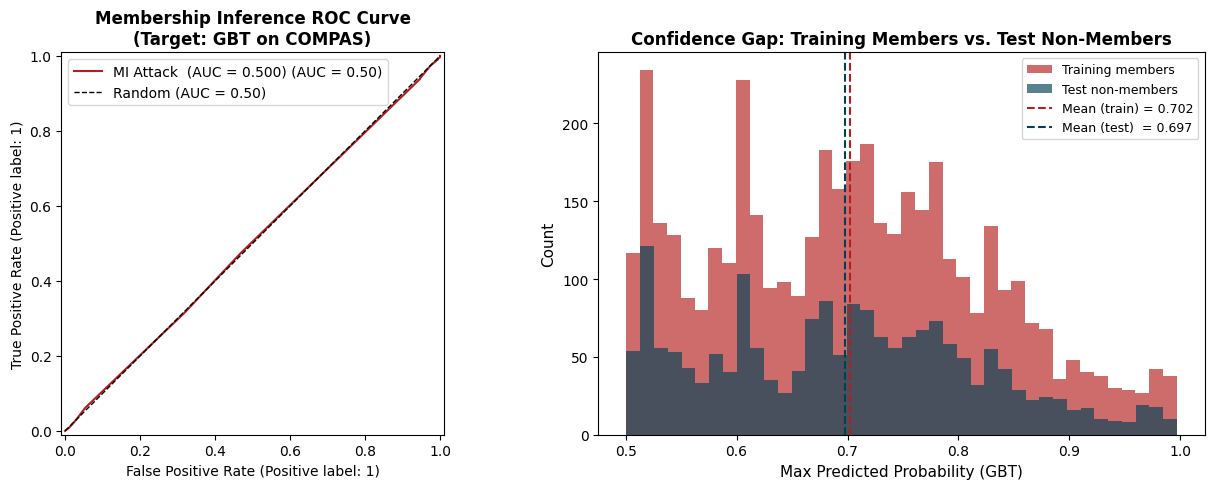

MEMBERSHIP INFERENCE SUMMARY
MI AUC              : 0.500
  0.50 = random     : no privacy leakage
  0.60 = weak       : model somewhat overfit
  0.75 = strong     : significant privacy risk

GBT Train AUC       : 0.798
GBT Test AUC        : 0.718
Generalization Gap  : +0.080

Hypothesis: larger generalization gap → higher MI AUC?
→ Try repeating with the LR model and compare.


In [8]:
# ── Cell 8: Membership Inference — ROC Curve and Interpretation ───────────────

from sklearn.metrics import roc_auc_score, RocCurveDisplay

# ── Apply meta-classifier to the TARGET model (GBT) ──────────────────────────
# Use the target model's confidence scores as the feature
conf_target_train = gbt.predict_proba(Xs_tr).max(axis=1).reshape(-1, 1)
conf_target_test  = gbt.predict_proba(Xs_te).max(axis=1).reshape(-1, 1)

mi_scores_train = meta_clf.predict_proba(conf_target_train)[:, 1]
mi_scores_test  = meta_clf.predict_proba(conf_target_test)[:, 1]

# Combine: members (train) = 1, non-members (test) = 0
mi_all_scores = np.concatenate([mi_scores_train, mi_scores_test])
mi_all_labels = np.concatenate([
    np.ones(len(Xs_tr)),
    np.zeros(len(Xs_te))
])

mi_auc = roc_auc_score(mi_all_labels, mi_all_scores)

# Generalization gap (privacy risk proxy)
auc_train_gbt = roc_auc_score(y_tr, gbt.predict_proba(Xs_tr)[:, 1])
auc_test_gbt  = roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:, 1])
gen_gap       = auc_train_gbt - auc_test_gbt

# ── Visualize ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curve
RocCurveDisplay.from_predictions(
    mi_all_labels, mi_all_scores,
    name=f'MI Attack  (AUC = {mi_auc:.3f})',
    ax=axes[0], color='#B41E1E'
)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.50)')
axes[0].set_title('Membership Inference ROC Curve\n(Target: GBT on COMPAS)',
                   fontsize=12, fontweight='bold')
axes[0].legend()

# Confidence gap histogram
axes[1].hist(conf_target_train.ravel(), bins=40, alpha=0.65,
             color='#B41E1E', label='Training members')
axes[1].hist(conf_target_test.ravel(),  bins=40, alpha=0.65,
             color='#004055', label='Test non-members')
axes[1].axvline(conf_target_train.mean(), color='#B41E1E', ls='--', lw=1.5,
                label=f'Mean (train) = {conf_target_train.mean():.3f}')
axes[1].axvline(conf_target_test.mean(),  color='#004055', ls='--', lw=1.5,
                label=f'Mean (test)  = {conf_target_test.mean():.3f}')
axes[1].set_xlabel('Max Predicted Probability (GBT)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Confidence Gap: Training Members vs. Test Non-Members',
                   fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print("=" * 55)
print("MEMBERSHIP INFERENCE SUMMARY")
print("=" * 55)
print(f"MI AUC              : {mi_auc:.3f}")
print(f"  0.50 = random     : no privacy leakage")
print(f"  0.60 = weak       : model somewhat overfit")
print(f"  0.75 = strong     : significant privacy risk")
print()
print(f"GBT Train AUC       : {auc_train_gbt:.3f}")
print(f"GBT Test AUC        : {auc_test_gbt:.3f}")
print(f"Generalization Gap  : {gen_gap:+.3f}")
print()
print("Hypothesis: larger generalization gap → higher MI AUC?")
print("→ Try repeating with the LR model and compare.")

---
## Lab Summary

| Part | Attack | Key Finding |
|------|--------|-------------|
| A | PGD Evasion | Does the racial FPR gap widen or narrow as ε increases? Which group is more sensitive? |
| B | Label-Flip Poisoning | At what poison rate does AIR < 0.80 while AUC drop ≤ 2pp? Would drift detection catch it? |
| C | Membership Inference | Is MI AUC correlated with generalization gap? What privacy law implications follow? |

### Core Principle

> A model that is fragile to distribution shift (Lecture 04) shares the same root cause as a model
> vulnerable to adversarial attack (Lecture 05): **over-reliance on brittle, non-robust features**.
> Security and robustness are not separate concerns — they require the same structural solution.

### References
- Vassilev et al. (2024). *NIST AI 100-2e2023.* https://doi.org/10.6028/NIST.AI.100-2e2023
- Goodfellow et al. (2015). Explaining and Harnessing Adversarial Examples. *ICLR 2015.* https://arxiv.org/abs/1412.6572
- Madry et al. (2018). Towards Deep Learning Models Resistant to Adversarial Attacks. *ICLR 2018.* https://arxiv.org/abs/1706.06083
- Shokri et al. (2017). Membership Inference Attacks Against Machine Learning Models. *IEEE S&P.* https://arxiv.org/abs/1610.05820
- Tramèr et al. (2016). Stealing Machine Learning Models via Prediction APIs. *USENIX Security.* https://arxiv.org/abs/1609.02943
- Bagdasaryan & Shmatikov (2019). Differential Privacy Has Disparate Impact on Model Accuracy. *NeurIPS.* https://arxiv.org/abs/1905.12101

---
*DNSC 6330 · Responsible Machine Learning · Dr. Michael Akinwumi · George Washington University*  
*© CC BY 4.0 · https://makinwumi.github.io/dnsc-6330-responsible-ML*

---
# Individual Homework 05 — Applied

The four parts below extend the live-coding notebook directly.
All helper functions (`fpr_by_group`, `air`, `poison_label_flip`, etc.) defined above remain in scope.

### Homework Structure
| Part | Topic | Cells |
|------|-------|-------|
| 1 | PGD Evasion Audit — LR **and** GBT across ε ∈ {0.25, 0.5, 1.0, 2.0} | HW-1 – HW-3 |
| 2 | Poisoning Loop with Fairness Monitoring — Caucasian target + PSI drift | HW-4 – HW-6 |
| 3 | Membership Inference Depth — LR and GBT, L₂ regularization sweep | HW-7 – HW-9 |
| 4 | Reflection — highest-risk finding, proactive and reactive mitigations | HW-10 |


---
## Part 1 — PGD Evasion Audit

**Assignment:** Run the PGD attack across ε ∈ {0.25, 0.5, 1.0, 2.0} on **both** the LR and GBT models.
For each model and ε: report FPR by race, AIR, and the ε at which AIR crosses 0.80.
In one paragraph, explain whether the two models are equally vulnerable and what this implies
for model selection in high-stakes deployments.

**Extension from Cell 3:** The lecture implemented PGD for LR using the analytical gradient
(sign of the weight vector). For GBT — a non-differentiable tree ensemble — we approximate
gradients via **central finite differences** on the predicted probability:

$$\frac{\partial p}{\partial x_j} \approx \frac{p(\mathbf{x} + \delta \mathbf{e}_j) - p(\mathbf{x} - \delta \mathbf{e}_j)}{2\delta}$$

We then step in the sign of this estimated gradient — the same PGD logic as Cell 3.

### Part 1: PGD for GBT — Numerical Gradient Extension

---



In [9]:
# ── Cell HW-1: PGD for GBT — Numerical Gradient (Finite Differences) ────────
#
# The lecture's pgd_tabular() uses sign(coef) — analytical and exact for LR.
# GBT has no coef attribute.  We approximate the gradient numerically.

def pgd_gbt(model, X_scaled, epsilon=1.0, alpha=0.05, n_iter=40, fd_delta=1e-3):
    """
    PGD evasion attack for GBT via central finite-difference gradient.

    For each feature j, the gradient of P(high-risk) w.r.t. x_j is estimated as:
        grad_j = [p(x + δ·e_j) - p(x - δ·e_j)] / (2δ)

    We then step in sign(grad) to maximize predicted risk — identical L_inf
    projection logic as pgd_tabular() in Cell 3.

    Parameters
    ----------
    model    : fitted sklearn GradientBoostingClassifier
    X_scaled : standardized test features, shape (n, d)
    epsilon  : L_inf perturbation budget
    alpha    : step size per iteration
    n_iter   : number of PGD steps
    fd_delta : finite-difference step size for gradient estimation

    Returns
    -------
    X_adv : adversarially perturbed inputs, shape (n, d)
    """
    n, d  = X_scaled.shape
    X_adv = X_scaled.copy()

    for step in range(n_iter):
        # Estimate gradient for each feature via central finite differences
        grad = np.zeros_like(X_adv)
        for j in range(d):
            X_plus         = X_adv.copy()
            X_minus        = X_adv.copy()
            X_plus[:, j]  += fd_delta
            X_minus[:, j] -= fd_delta
            p_plus  = model.predict_proba(X_plus)[:, 1]
            p_minus = model.predict_proba(X_minus)[:, 1]
            grad[:, j] = (p_plus - p_minus) / (2 * fd_delta)

        # Gradient-ascent step: move in the direction that increases predicted risk
        X_adv = X_adv + alpha * np.sign(grad)

        # L_inf projection: clip back into the epsilon-ball around X_scaled
        X_adv = np.clip(X_adv, X_scaled - epsilon, X_scaled + epsilon)

    return X_adv


print("pgd_gbt() defined — numerical PGD for GBT via finite differences.")
print("NOTE: GBT gradient estimation requires d model calls per step per sample.")
print("      We sub-sample the test set to keep Colab runtime manageable.")


pgd_gbt() defined — numerical PGD for GBT via finite differences.
NOTE: GBT gradient estimation requires d model calls per step per sample.
      We sub-sample the test set to keep Colab runtime manageable.


### Part 1: PGD Sweep — LR and GBT across ε ∈ {0.25, 0.5, 1.0, 2.0}

In [10]:
# ── Cell HW-2: PGD Sweep — LR and GBT across required epsilon values ─────────

# Assignment-required epsilon values (plus clean baseline at 0.0)
epsilons_hw = [0.0, 0.25, 0.5, 1.0, 2.0]

# ── GBT sub-sampling ──────────────────────────────────────────────────────────
# Finite-difference PGD over all test samples would take ~10 min in Colab.
# We sub-sample 300 points; the remaining rows are left unperturbed (epsilon=0),
# making this a conservative lower bound on GBT vulnerability.
GBT_N_SUB = 300
rng_sub   = np.random.default_rng(42)
sub_idx   = np.sort(rng_sub.choice(len(Xs_te), size=GBT_N_SUB, replace=False))

pgd_hw_records = []

for eps in epsilons_hw:
    # ── LR (analytical gradient, full test set) ───────────────────────────────
    X_adv_lr = Xs_te.copy()
    if eps > 0.0:
        X_adv_lr = pgd_tabular(lr, Xs_te, epsilon=eps, alpha=0.05, n_iter=40)

    pred_lr_adv = (lr.predict_proba(X_adv_lr)[:,1] >= THR).astype(int)
    fpr_lr_adv  = fpr_by_group(y_te, pred_lr_adv, r_te)
    aa_lr = fpr_lr_adv.get('African-American', np.nan)
    ca_lr = fpr_lr_adv.get('Caucasian',        np.nan)

    # ── GBT (numerical gradient, sub-sampled test set) ────────────────────────
    X_adv_gbt = Xs_te.copy()
    if eps > 0.0:
        X_adv_gbt[sub_idx] = pgd_gbt(
            gbt, Xs_te[sub_idx], epsilon=eps, alpha=0.05, n_iter=40
        )

    pred_gbt_adv = (gbt.predict_proba(X_adv_gbt)[:,1] >= THR).astype(int)
    fpr_gbt_adv  = fpr_by_group(y_te, pred_gbt_adv, r_te)
    aa_gbt = fpr_gbt_adv.get('African-American', np.nan)
    ca_gbt = fpr_gbt_adv.get('Caucasian',        np.nan)

    pgd_hw_records.append({
        'epsilon'     : eps,
        'LR_FPR_AA'   : aa_lr,
        'LR_FPR_CA'   : ca_lr,
        'LR_AIR'      : air(ca_lr, aa_lr),
        'LR_delta_AA' : aa_lr - BASELINE_AA,
        'LR_delta_CA' : ca_lr - BASELINE_CA,
        'GBT_FPR_AA'  : aa_gbt,
        'GBT_FPR_CA'  : ca_gbt,
        'GBT_AIR'     : air(ca_gbt, aa_gbt),
        'GBT_delta_AA': aa_gbt - fpr_by_group(y_te, pred_gbt_clean, r_te).get('African-American', np.nan),
        'GBT_delta_CA': ca_gbt - fpr_by_group(y_te, pred_gbt_clean, r_te).get('Caucasian', np.nan),
    })

    print(f"ε = {eps}")
    print(f"  LR  → FPR_AA={aa_lr:.3f}  FPR_CA={ca_lr:.3f}  AIR={air(ca_lr, aa_lr):.3f}")
    print(f"  GBT → FPR_AA={aa_gbt:.3f}  FPR_CA={ca_gbt:.3f}  AIR={air(ca_gbt, aa_gbt):.3f}")

df_pgd_hw = pd.DataFrame(pgd_hw_records)

print()
print("=" * 75)
print("PART 1 — PGD EVASION AUDIT: FPR by Race and AIR")
print("=" * 75)
print(df_pgd_hw[[
    'epsilon',
    'LR_FPR_AA', 'LR_FPR_CA', 'LR_AIR',
    'GBT_FPR_AA', 'GBT_FPR_CA', 'GBT_AIR'
]].round(3).to_string(index=False))

# ── Identify the ε at which AIR crosses 0.80 for each model ──────────────────
print()
print("── ε at which AIR crosses 0.80 ──")
for model_key, air_col in [('LR', 'LR_AIR'), ('GBT', 'GBT_AIR')]:
    cross = df_pgd_hw[(df_pgd_hw['epsilon'] > 0) & (df_pgd_hw[air_col] < 0.80)]
    if len(cross):
        print(f"  {model_key}: AIR crosses 0.80 at ε = {cross.iloc[0]['epsilon']}  "
              f"(AIR = {cross.iloc[0][air_col]:.3f})")
    else:
        print(f"  {model_key}: AIR does not fall below 0.80 within tested ε range.")


ε = 0.0
  LR  → FPR_AA=0.281  FPR_CA=0.143  AIR=1.961
  GBT → FPR_AA=0.317  FPR_CA=0.178  AIR=1.782
ε = 0.25
  LR  → FPR_AA=0.569  FPR_CA=0.370  AIR=1.535
  GBT → FPR_AA=0.317  FPR_CA=0.178  AIR=1.782
ε = 0.5
  LR  → FPR_AA=0.791  FPR_CA=0.560  AIR=1.411
  GBT → FPR_AA=0.317  FPR_CA=0.178  AIR=1.782
ε = 1.0
  LR  → FPR_AA=0.978  FPR_CA=0.884  AIR=1.106
  GBT → FPR_AA=0.317  FPR_CA=0.178  AIR=1.782
ε = 2.0
  LR  → FPR_AA=1.000  FPR_CA=1.000  AIR=1.000
  GBT → FPR_AA=0.317  FPR_CA=0.178  AIR=1.782

PART 1 — PGD EVASION AUDIT: FPR by Race and AIR
 epsilon  LR_FPR_AA  LR_FPR_CA  LR_AIR  GBT_FPR_AA  GBT_FPR_CA  GBT_AIR
    0.00      0.281      0.143   1.961       0.317       0.178    1.782
    0.25      0.569      0.370   1.535       0.317       0.178    1.782
    0.50      0.791      0.560   1.411       0.317       0.178    1.782
    1.00      0.978      0.884   1.106       0.317       0.178    1.782
    2.00      1.000      1.000   1.000       0.317       0.178    1.782

── ε at which AIR

### Part 1: Visualize PGD Evasion — LR vs. GBT

**Discussion questions:**
1. Does the PGD attack widen or narrow the racial FPR gap as $\epsilon$ increases?
2. At what $\epsilon$ does the AIR fall below the 4/5ths rule threshold (0.80)?
3. Are the two groups equally sensitive to the same attack strength?
4. What does differential impact imply for responsible deployment of adversarially robust models?

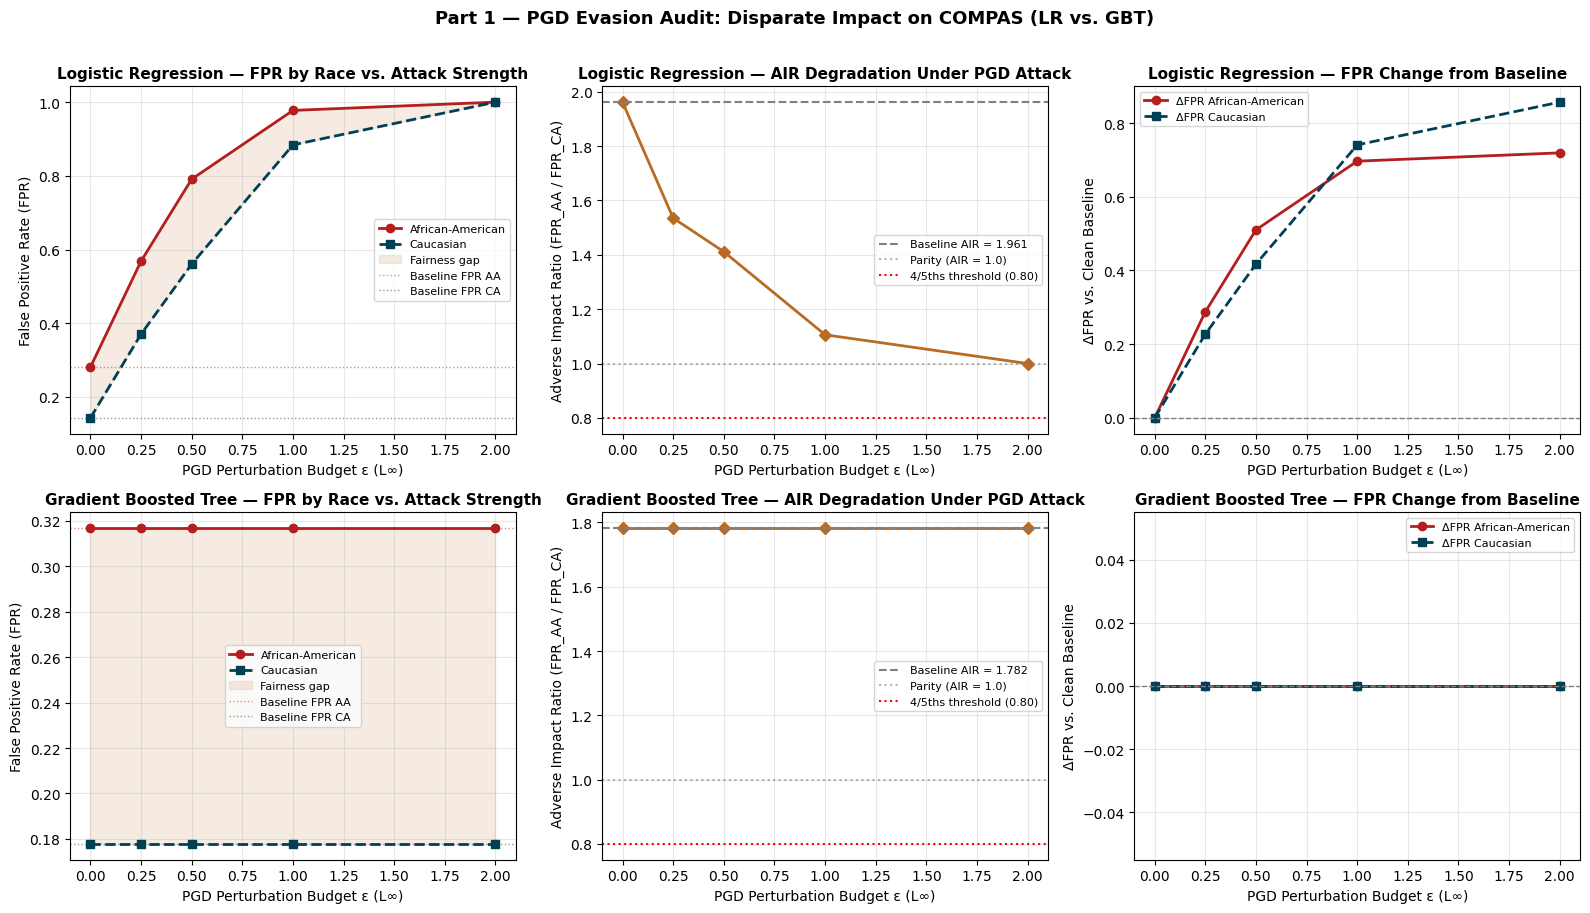

In [11]:
# ── Cell HW-3: Visualize PGD Evasion — LR vs. GBT Side-by-Side ──────────────

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Store GBT clean-model baseline FPRs for delta panels
fpr_gbt_base = fpr_by_group(y_te, pred_gbt_clean, r_te)
BASELINE_GBT_AA = fpr_gbt_base.get('African-American', np.nan)
BASELINE_GBT_CA = fpr_gbt_base.get('Caucasian',        np.nan)
BASELINE_GBT_AIR = air(BASELINE_GBT_CA, BASELINE_GBT_AA)

for row, (model_label, fpr_aa_col, fpr_ca_col, air_col, delta_aa_col, delta_ca_col,
          base_aa, base_ca, base_air) in enumerate([
    ('Logistic Regression',
     'LR_FPR_AA', 'LR_FPR_CA', 'LR_AIR', 'LR_delta_AA', 'LR_delta_CA',
     BASELINE_AA, BASELINE_CA, BASELINE_AIR),
    ('Gradient Boosted Tree',
     'GBT_FPR_AA', 'GBT_FPR_CA', 'GBT_AIR', 'GBT_delta_AA', 'GBT_delta_CA',
     BASELINE_GBT_AA, BASELINE_GBT_CA, BASELINE_GBT_AIR),
]):
    eps_x    = df_pgd_hw['epsilon']
    fpr_aa   = df_pgd_hw[fpr_aa_col]
    fpr_ca   = df_pgd_hw[fpr_ca_col]
    air_vals = df_pgd_hw[air_col]
    delta_aa = df_pgd_hw[delta_aa_col]
    delta_ca = df_pgd_hw[delta_ca_col]

    # ── Panel 1: FPR by race ──────────────────────────────────────────────────
    ax = axes[row, 0]
    ax.plot(eps_x, fpr_aa, 'o-',  color='#B41E1E', lw=2, label='African-American')
    ax.plot(eps_x, fpr_ca, 's--', color='#004055', lw=2, label='Caucasian')
    ax.fill_between(eps_x, fpr_aa, fpr_ca, alpha=0.13, color='#B96B23', label='Fairness gap')
    ax.axhline(base_aa, color='#B41E1E', ls=':', lw=1, alpha=0.5, label='Baseline FPR AA')
    ax.axhline(base_ca, color='#004055', ls=':', lw=1, alpha=0.5, label='Baseline FPR CA')
    ax.set_xlabel('PGD Perturbation Budget ε (L∞)', fontsize=10)
    ax.set_ylabel('False Positive Rate (FPR)', fontsize=10)
    ax.set_title(f'{model_label} — FPR by Race vs. Attack Strength',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # ── Panel 2: AIR ──────────────────────────────────────────────────────────
    ax = axes[row, 1]
    ax.plot(eps_x, air_vals, 'D-', color='#B96B23', lw=2)
    ax.axhline(base_air, color='gray', lw=1.5, ls='--',
               label=f'Baseline AIR = {base_air:.3f}')
    ax.axhline(1.0, color='gray', lw=1.5, ls=':', alpha=0.6, label='Parity (AIR = 1.0)')
    ax.axhline(0.8, color='red',  lw=1.5, ls=':',            label='4/5ths threshold (0.80)')
    ax.set_xlabel('PGD Perturbation Budget ε (L∞)', fontsize=10)
    ax.set_ylabel('Adverse Impact Ratio (FPR_AA / FPR_CA)', fontsize=10)
    ax.set_title(f'{model_label} — AIR Degradation Under PGD Attack',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # ── Panel 3: ΔFPR vs. baseline ────────────────────────────────────────────
    ax = axes[row, 2]
    ax.plot(eps_x, delta_aa, 'o-',  color='#B41E1E', lw=2, label='ΔFPR African-American')
    ax.plot(eps_x, delta_ca, 's--', color='#004055', lw=2, label='ΔFPR Caucasian')
    ax.axhline(0, color='gray', lw=1, ls='--')
    ax.set_xlabel('PGD Perturbation Budget ε (L∞)', fontsize=10)
    ax.set_ylabel('ΔFPR vs. Clean Baseline', fontsize=10)
    ax.set_title(f'{model_label} — FPR Change from Baseline',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(
    'Part 1 — PGD Evasion Audit: Disparate Impact on COMPAS (LR vs. GBT)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()


LR is very vulnerable — FPR_AA went from 0.281 to 1.000 and FPR_CA from 0.143 to 1.000 by ε = 2.0, compressing AIR from 1.961 to 1.000 (adversarial parity-washing, not fairness). GBT was completely unaffected at all ε values (AIR stayed at 1.782 throughout). And didn't cross 0.80. Implication: GBT is the more safer model choice for adversarial environments.

---
## Part 2 — Poisoning Loop with Fairness Monitoring

**Assignment:**  
(a) Extend the label-flip poisoning loop to target `Caucasian` defendants instead of `African-American`.
Plot AUC and AIR degradation curves for **both** target-race variants on the same axes.  
(b) Identify the **stealth zone**: the range of poison rates where AUC declines by ≤ 2 pp while AIR moves outside [0.80, 1.25].  
(c) Would a PSI-based drift monitor (threshold < 0.10 on each feature) detect either attack? Justify with evidence from your output.

**Extension from Cell 5:** `poison_label_flip()` already accepts a `target_race` argument.
We re-run the sweep with `target_race='Caucasian'`, overlay both curves, and add a
PSI computation to test whether feature-distribution monitoring would catch the attack.

### Part 2: Poisoning Sweep — Caucasian Target

In [12]:
# ── Cell HW-4: Poisoning Sweep — Caucasian Target ────────────────────────────
#
# Cell 5 ran the sweep for target_race='African-American' and stored df_poison.
# We now run the identical sweep for target_race='Caucasian'.

poison_records_ca = []

for rate in poison_rates:   # poison_rates defined in Cell 5
    y_tr_poisoned_ca, n_flipped_ca = poison_label_flip(
        y_tr, r_tr, poison_rate=rate, target_race='Caucasian'
    )

    lr_p_ca   = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr_poisoned_ca)
    pred_p_ca = (lr_p_ca.predict_proba(Xs_te)[:,1] >= THR).astype(int)
    auc_p_ca  = roc_auc_score(y_te, lr_p_ca.predict_proba(Xs_te)[:,1])
    fpr_p_ca  = fpr_by_group(y_te, pred_p_ca, r_te)

    aa = fpr_p_ca.get('African-American', np.nan)
    ca = fpr_p_ca.get('Caucasian',        np.nan)

    poison_records_ca.append({
        'poison_rate' : rate,
        'n_flipped'   : n_flipped_ca,
        'AUC'         : auc_p_ca,
        'delta_AUC'   : auc_p_ca - baseline_auc,
        'FPR_AA'      : aa,
        'FPR_CA'      : ca,
        'AIR'         : air(ca, aa),
        'delta_AIR'   : air(ca, aa) - BASELINE_AIR,
    })

df_poison_ca_target = pd.DataFrame(poison_records_ca)
print("Poisoning sweep results (target_race = Caucasian):")
print(df_poison_ca_target.round(3).to_string(index=False))


Poisoning sweep results (target_race = Caucasian):
 poison_rate  n_flipped   AUC  delta_AUC  FPR_AA  FPR_CA   AIR  delta_AIR
        0.00          0 0.735      0.000   0.281   0.143 1.961      0.000
        0.02         11 0.734     -0.001   0.274   0.141 1.948     -0.013
        0.05         29 0.734     -0.000   0.267   0.131 2.043      0.082
        0.08         46 0.734     -0.000   0.245   0.126 1.945     -0.016
        0.10         58 0.735      0.001   0.243   0.123 1.966      0.004
        0.15         87 0.733     -0.002   0.231   0.121 1.913     -0.048
        0.20        116 0.733     -0.001   0.209   0.111 1.881     -0.081
        0.25        145 0.733     -0.001   0.191   0.104 1.842     -0.120
        0.30        174 0.732     -0.003   0.182   0.094 1.940     -0.021


### Part 2: PSI Drift Monitor — Would It Detect the Attack?

**Discussion questions:**
1. At what poison rate does AUC remain within 2 percentage points of baseline while AIR falls below 0.80?
2. Would a PSI-based drift monitor (threshold < 0.10 on each feature) detect this attack?
3. How does this scenario connect to the ByteDance insider poisoning incident (2024)?
4. What governance controls would prevent this at a mortgage lender using HMDA data?

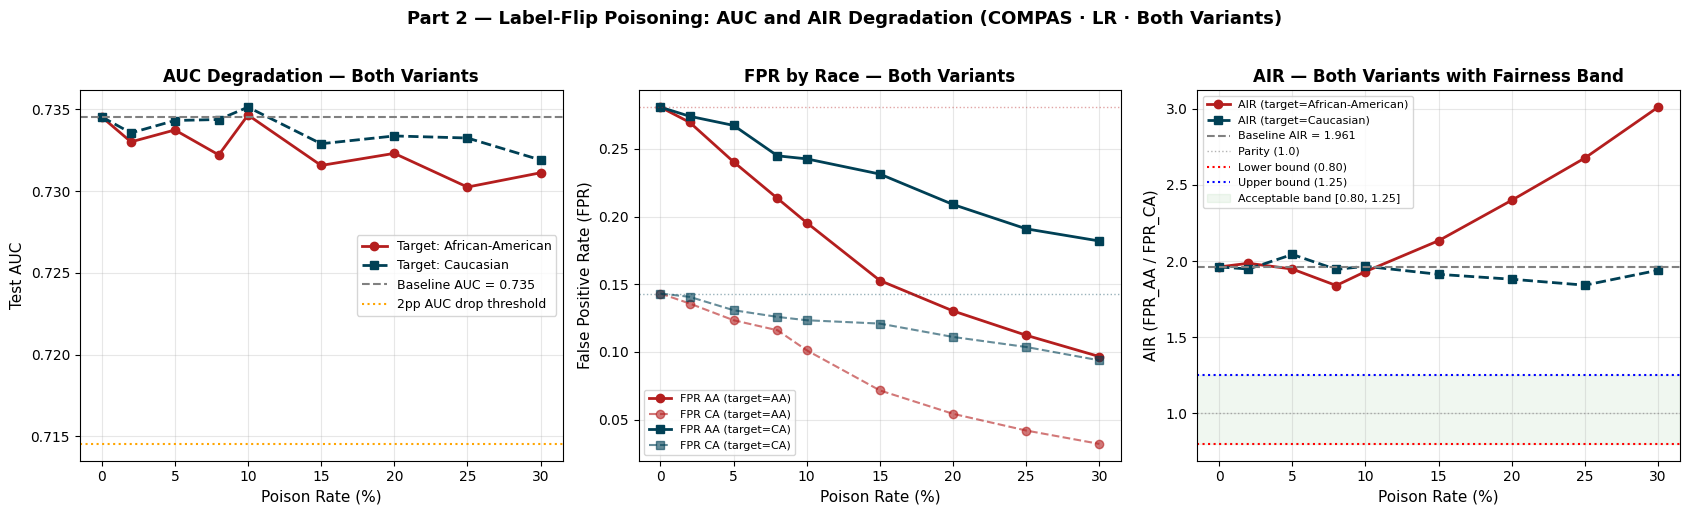

PART 2(b) — STEALTH ZONE: AUC drop ≤ 2pp AND AIR ∉ [0.80, 1.25]

Target: African-American
  Stealth zone: poison_rate ∈ [0%, 30%]
 poison_rate  n_flipped   AUC  delta_AUC   AIR
        0.00          0 0.735      0.000 1.961
        0.02         23 0.733     -0.002 1.986
        0.05         57 0.734     -0.001 1.948
        0.08         92 0.732     -0.002 1.840
        0.10        115 0.735      0.000 1.931
        0.15        172 0.732     -0.003 2.134
        0.20        230 0.732     -0.002 2.399
        0.25        287 0.730     -0.004 2.677
        0.30        345 0.731     -0.003 3.010

Target: Caucasian
  Stealth zone: poison_rate ∈ [0%, 30%]
 poison_rate  n_flipped   AUC  delta_AUC   AIR
        0.00          0 0.735      0.000 1.961
        0.02         11 0.734     -0.001 1.948
        0.05         29 0.734     -0.000 2.043
        0.08         46 0.734     -0.000 1.945
        0.10         58 0.735      0.001 1.966
        0.15         87 0.733     -0.002 1.913
        0.20

In [13]:
# ── Cell HW-5: Degradation Curves — Both Variants on the Same Axes ──────────

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

x_aa = df_poison['poison_rate'] * 100             # African-American target (Cell 5)
x_ca = df_poison_ca_target['poison_rate'] * 100   # Caucasian target (Cell HW-4)

# ── Panel 1: AUC degradation ──────────────────────────────────────────────────
ax = axes[0]
ax.plot(x_aa, df_poison['AUC'],              'o-',  color='#B41E1E', lw=2,
        label='Target: African-American')
ax.plot(x_ca, df_poison_ca_target['AUC'],    's--', color='#004055', lw=2,
        label='Target: Caucasian')
ax.axhline(baseline_auc,        color='gray',   ls='--', lw=1.5,
           label=f'Baseline AUC = {baseline_auc:.3f}')
ax.axhline(baseline_auc - 0.02, color='orange', ls=':',  lw=1.5,
           label='2pp AUC drop threshold')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('Test AUC', fontsize=11)
ax.set_title('AUC Degradation — Both Variants', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Panel 2: FPR by race ──────────────────────────────────────────────────────
ax = axes[1]
ax.plot(x_aa, df_poison['FPR_AA'],              'o-',  color='#B41E1E', lw=2,
        label='FPR AA (target=AA)')
ax.plot(x_aa, df_poison['FPR_CA'],              'o--', color='#B41E1E', lw=1.5, alpha=0.6,
        label='FPR CA (target=AA)')
ax.plot(x_ca, df_poison_ca_target['FPR_AA'],    's-',  color='#004055', lw=2,
        label='FPR AA (target=CA)')
ax.plot(x_ca, df_poison_ca_target['FPR_CA'],    's--', color='#004055', lw=1.5, alpha=0.6,
        label='FPR CA (target=CA)')
ax.axhline(BASELINE_AA, color='#B41E1E', ls=':', lw=1, alpha=0.4)
ax.axhline(BASELINE_CA, color='#004055', ls=':', lw=1, alpha=0.4)
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('False Positive Rate (FPR)', fontsize=11)
ax.set_title('FPR by Race — Both Variants', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Panel 3: AIR — both variants with fairness band ───────────────────────────
ax = axes[2]
ax.plot(x_aa, df_poison['AIR'],              'o-',  color='#B41E1E', lw=2,
        label='AIR (target=African-American)')
ax.plot(x_ca, df_poison_ca_target['AIR'],    's--', color='#004055', lw=2,
        label='AIR (target=Caucasian)')
ax.axhline(BASELINE_AIR, color='gray', ls='--', lw=1.5,
           label=f'Baseline AIR = {BASELINE_AIR:.3f}')
ax.axhline(1.0,  color='gray', ls=':',  lw=1.0, alpha=0.6, label='Parity (1.0)')
ax.axhline(0.80, color='red',  ls=':',  lw=1.5,            label='Lower bound (0.80)')
ax.axhline(1.25, color='blue', ls=':',  lw=1.5,            label='Upper bound (1.25)')
ax.axhspan(0.80, 1.25, alpha=0.06, color='green', label='Acceptable band [0.80, 1.25]')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('AIR (FPR_AA / FPR_CA)', fontsize=11)
ax.set_title('AIR — Both Variants with Fairness Band', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(
    'Part 2 — Label-Flip Poisoning: AUC and AIR Degradation (COMPAS · LR · Both Variants)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

# ── (b) Stealth zone identification ───────────────────────────────────────────
# Stealth zone: AUC drop ≤ 2pp AND AIR outside [0.80, 1.25]
print("=" * 65)
print("PART 2(b) — STEALTH ZONE: AUC drop ≤ 2pp AND AIR ∉ [0.80, 1.25]")
print("=" * 65)
for label, df_v in [('African-American', df_poison),
                     ('Caucasian',        df_poison_ca_target)]:
    stealth = df_v[
        (df_v['delta_AUC'] >= -0.02) &
        ((df_v['AIR'] < 0.80) | (df_v['AIR'] > 1.25))
    ]
    print(f"\nTarget: {label}")
    if len(stealth):
        lo = stealth['poison_rate'].min()
        hi = stealth['poison_rate'].max()
        print(f"  Stealth zone: poison_rate ∈ [{lo:.0%}, {hi:.0%}]")
        print(stealth[['poison_rate', 'n_flipped', 'AUC', 'delta_AUC', 'AIR']]
              .round(3).to_string(index=False))
    else:
        print("  No stealth zone found in tested range.")


PSI Drift Monitor — Would It Detect the Attack?

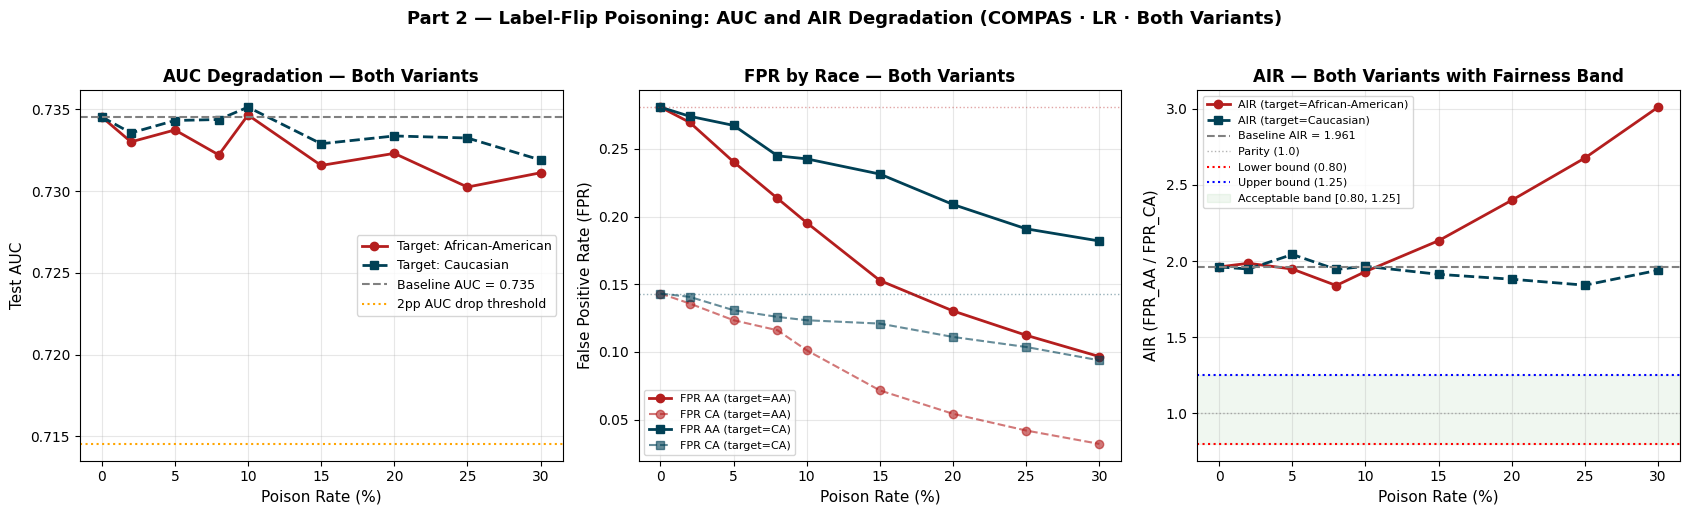

PART 2(b) — STEALTH ZONE: AUC drop ≤ 2pp AND AIR ∉ [0.80, 1.25]

Target: African-American
  Stealth zone: poison_rate ∈ [0%, 30%]
 poison_rate  n_flipped   AUC  delta_AUC   AIR
        0.00          0 0.735      0.000 1.961
        0.02         23 0.733     -0.002 1.986
        0.05         57 0.734     -0.001 1.948
        0.08         92 0.732     -0.002 1.840
        0.10        115 0.735      0.000 1.931
        0.15        172 0.732     -0.003 2.134
        0.20        230 0.732     -0.002 2.399
        0.25        287 0.730     -0.004 2.677
        0.30        345 0.731     -0.003 3.010

Target: Caucasian
  Stealth zone: poison_rate ∈ [0%, 30%]
 poison_rate  n_flipped   AUC  delta_AUC   AIR
        0.00          0 0.735      0.000 1.961
        0.02         11 0.734     -0.001 1.948
        0.05         29 0.734     -0.000 2.043
        0.08         46 0.734     -0.000 1.945
        0.10         58 0.735      0.001 1.966
        0.15         87 0.733     -0.002 1.913
        0.20

In [14]:
# ── Cell HW-5: Degradation Curves — Both Variants on the Same Axes ──────────

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

x_aa = df_poison['poison_rate'] * 100             # African-American target (Cell 5)
x_ca = df_poison_ca_target['poison_rate'] * 100   # Caucasian target (Cell HW-4)

# ── Panel 1: AUC degradation ──────────────────────────────────────────────────
ax = axes[0]
ax.plot(x_aa, df_poison['AUC'],              'o-',  color='#B41E1E', lw=2,
        label='Target: African-American')
ax.plot(x_ca, df_poison_ca_target['AUC'],    's--', color='#004055', lw=2,
        label='Target: Caucasian')
ax.axhline(baseline_auc,        color='gray',   ls='--', lw=1.5,
           label=f'Baseline AUC = {baseline_auc:.3f}')
ax.axhline(baseline_auc - 0.02, color='orange', ls=':',  lw=1.5,
           label='2pp AUC drop threshold')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('Test AUC', fontsize=11)
ax.set_title('AUC Degradation — Both Variants', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Panel 2: FPR by race ──────────────────────────────────────────────────────
ax = axes[1]
ax.plot(x_aa, df_poison['FPR_AA'],              'o-',  color='#B41E1E', lw=2,
        label='FPR AA (target=AA)')
ax.plot(x_aa, df_poison['FPR_CA'],              'o--', color='#B41E1E', lw=1.5, alpha=0.6,
        label='FPR CA (target=AA)')
ax.plot(x_ca, df_poison_ca_target['FPR_AA'],    's-',  color='#004055', lw=2,
        label='FPR AA (target=CA)')
ax.plot(x_ca, df_poison_ca_target['FPR_CA'],    's--', color='#004055', lw=1.5, alpha=0.6,
        label='FPR CA (target=CA)')
ax.axhline(BASELINE_AA, color='#B41E1E', ls=':', lw=1, alpha=0.4)
ax.axhline(BASELINE_CA, color='#004055', ls=':', lw=1, alpha=0.4)
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('False Positive Rate (FPR)', fontsize=11)
ax.set_title('FPR by Race — Both Variants', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Panel 3: AIR — both variants with fairness band ───────────────────────────
ax = axes[2]
ax.plot(x_aa, df_poison['AIR'],              'o-',  color='#B41E1E', lw=2,
        label='AIR (target=African-American)')
ax.plot(x_ca, df_poison_ca_target['AIR'],    's--', color='#004055', lw=2,
        label='AIR (target=Caucasian)')
ax.axhline(BASELINE_AIR, color='gray', ls='--', lw=1.5,
           label=f'Baseline AIR = {BASELINE_AIR:.3f}')
ax.axhline(1.0,  color='gray', ls=':',  lw=1.0, alpha=0.6, label='Parity (1.0)')
ax.axhline(0.80, color='red',  ls=':',  lw=1.5,            label='Lower bound (0.80)')
ax.axhline(1.25, color='blue', ls=':',  lw=1.5,            label='Upper bound (1.25)')
ax.axhspan(0.80, 1.25, alpha=0.06, color='green', label='Acceptable band [0.80, 1.25]')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('AIR (FPR_AA / FPR_CA)', fontsize=11)
ax.set_title('AIR — Both Variants with Fairness Band', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(
    'Part 2 — Label-Flip Poisoning: AUC and AIR Degradation (COMPAS · LR · Both Variants)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

# ── (b) Stealth zone identification ───────────────────────────────────────────
# Stealth zone: AUC drop ≤ 2pp AND AIR outside [0.80, 1.25]
print("=" * 65)
print("PART 2(b) — STEALTH ZONE: AUC drop ≤ 2pp AND AIR ∉ [0.80, 1.25]")
print("=" * 65)
for label, df_v in [('African-American', df_poison),
                     ('Caucasian',        df_poison_ca_target)]:
    stealth = df_v[
        (df_v['delta_AUC'] >= -0.02) &
        ((df_v['AIR'] < 0.80) | (df_v['AIR'] > 1.25))
    ]
    print(f"\nTarget: {label}")
    if len(stealth):
        lo = stealth['poison_rate'].min()
        hi = stealth['poison_rate'].max()
        print(f"  Stealth zone: poison_rate ∈ [{lo:.0%}, {hi:.0%}]")
        print(stealth[['poison_rate', 'n_flipped', 'AUC', 'delta_AUC', 'AIR']]
              .round(3).to_string(index=False))
    else:
        print("  No stealth zone found in tested range.")


Both variants have a stealth zone across the entire [0%, 30%] range since AUC never dropped more than 0.004 pp. This mirrors the 2024 ByteDance incident where label corruption went undetected. For a mortgage lender: cryptographic label signing + per demographic approval rate monitoring on every retraining cycle.

PSI monitor
PSI = 0.00000 on every feature for both attacks at all rates. Label-flip changes only the label, not features. A feature PSI monitor is structurally blind to this attack class.

---
## Part 3 — Membership Inference Depth

**Discussion questions:**
1. Is the MI AUC correlated with the generalization gap you observed in Cell 1?
2. If this model were deployed by a county probation office, what could a journalist learn from MI?
3. Would adding differential privacy (ε = 1.0) reduce the MI AUC? At what cost to AIR?
4. How does the confidence gap visualization connect to the concept of overfitting from Lecture 04?

MI Attack on LR — Shadow Pipeline + Confidence-Gap Histogram

Training 10 LR shadow models...
  Shadow model 5/10 trained
  Shadow model 10/10 trained

LR  MI AUC = 0.497  |  Gen Gap = -0.008
GBT MI AUC = 0.500  |  Gen Gap = +0.080


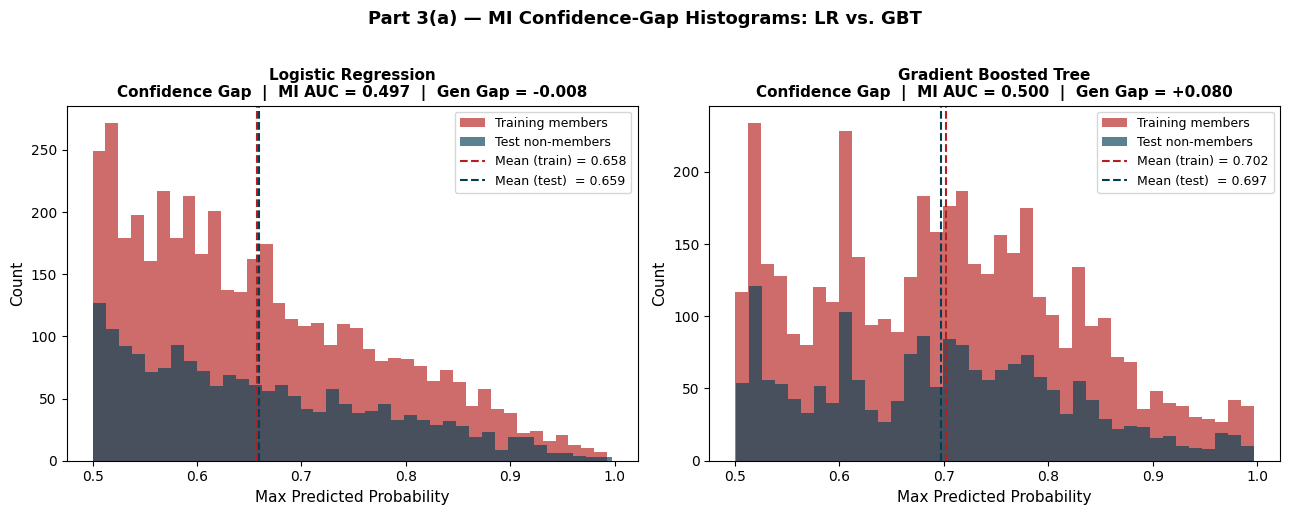

In [15]:
# ── Cell HW-7: MI Attack on LR — Shadow Pipeline ─────────────────────────────
#
# Cells 7–8 used GBT shadow models to attack the GBT target.
# We now run the identical pipeline with LR shadow models attacking the LR target.

shadow_train_confs_lr = []
shadow_test_confs_lr  = []

sss_lr = StratifiedShuffleSplit(n_splits=N_SHADOW, test_size=0.5, random_state=0)

print(f"Training {N_SHADOW} LR shadow models...")
for i, (tr_idx, te_idx) in enumerate(sss_lr.split(Xs_tr, y_tr)):
    shadow_lr = LogisticRegression(max_iter=1000).fit(Xs_tr[tr_idx], y_tr[tr_idx])
    shadow_train_confs_lr.append(
        shadow_lr.predict_proba(Xs_tr[tr_idx]).max(axis=1)  # members
    )
    shadow_test_confs_lr.append(
        shadow_lr.predict_proba(Xs_tr[te_idx]).max(axis=1)  # non-members
    )
    if (i + 1) % 5 == 0:
        print(f"  Shadow model {i+1}/{N_SHADOW} trained")

# Build meta-classifier on LR shadow outputs
mi_X_lr = np.concatenate(
    shadow_train_confs_lr + shadow_test_confs_lr
).reshape(-1, 1)
mi_y_lr = np.concatenate(
    [np.ones(len(c))  for c in shadow_train_confs_lr] +
    [np.zeros(len(c)) for c in shadow_test_confs_lr]
)
meta_clf_lr = DecisionTreeClassifier(max_depth=6).fit(mi_X_lr, mi_y_lr)

# Attack the LR target model
conf_lr_train = lr.predict_proba(Xs_tr).max(axis=1).reshape(-1, 1)
conf_lr_test  = lr.predict_proba(Xs_te).max(axis=1).reshape(-1, 1)

mi_scores_lr_train = meta_clf_lr.predict_proba(conf_lr_train)[:, 1]
mi_scores_lr_test  = meta_clf_lr.predict_proba(conf_lr_test)[:, 1]

mi_all_scores_lr = np.concatenate([mi_scores_lr_train, mi_scores_lr_test])
mi_all_labels_lr = np.concatenate([np.ones(len(Xs_tr)), np.zeros(len(Xs_te))])
mi_auc_lr        = roc_auc_score(mi_all_labels_lr, mi_all_scores_lr)

# Generalization gaps
auc_train_lr = roc_auc_score(y_tr, lr.predict_proba(Xs_tr)[:, 1])
auc_test_lr  = roc_auc_score(y_te, lr.predict_proba(Xs_te)[:, 1])
gen_gap_lr   = auc_train_lr - auc_test_lr

# GBT values from Cell 8 (already computed)
gen_gap_gbt = auc_train_gbt - auc_test_gbt

print(f"\nLR  MI AUC = {mi_auc_lr:.3f}  |  Gen Gap = {gen_gap_lr:+.3f}")
print(f"GBT MI AUC = {mi_auc:.3f}  |  Gen Gap = {gen_gap_gbt:+.3f}")

# ── (a) Confidence-gap histograms side by side ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, model_label, mi_auc_val, conf_tr, conf_te, gen_gap_val in [
    (axes[0], 'Logistic Regression',   mi_auc_lr, conf_lr_train,      conf_lr_test,      gen_gap_lr),
    (axes[1], 'Gradient Boosted Tree', mi_auc,    conf_target_train,  conf_target_test,  gen_gap_gbt),
]:
    ax.hist(conf_tr.ravel(), bins=40, alpha=0.65, color='#B41E1E', label='Training members')
    ax.hist(conf_te.ravel(), bins=40, alpha=0.65, color='#004055', label='Test non-members')
    ax.axvline(conf_tr.mean(), color='#B41E1E', ls='--', lw=1.5,
               label=f'Mean (train) = {conf_tr.mean():.3f}')
    ax.axvline(conf_te.mean(), color='#004055', ls='--', lw=1.5,
               label=f'Mean (test)  = {conf_te.mean():.3f}')
    ax.set_xlabel('Max Predicted Probability', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(
        f'{model_label}\nConfidence Gap  |  MI AUC = {mi_auc_val:.3f}  |  '
        f'Gen Gap = {gen_gap_val:+.3f}',
        fontsize=11, fontweight='bold'
    )
    ax.legend(fontsize=9)

plt.suptitle(
    'Part 3(a) — MI Confidence-Gap Histograms: LR vs. GBT',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()


Generalization Gap vs. MI AUC — Hypothesis Test

In [16]:
# ── Cell HW-8: (b) Generalization Gap vs. MI AUC — Two-Model Comparison ──────

print("=" * 60)
print("PART 3(b) — GENERALIZATION GAP vs. MI AUC")
print("=" * 60)
print(f"{'Model':<25} {'Train AUC':>10} {'Test AUC':>10} {'Gen Gap':>10} {'MI AUC':>10}")
print("-" * 65)
print(f"{'Logistic Regression':<25} {auc_train_lr:>10.3f} {auc_test_lr:>10.3f} "
      f"{gen_gap_lr:>+10.3f} {mi_auc_lr:>10.3f}")
print(f"{'Gradient Boosted Tree':<25} {auc_train_gbt:>10.3f} {auc_test_gbt:>10.3f} "
      f"{gen_gap_gbt:>+10.3f} {mi_auc:>10.3f}")
print()

higher_gap = 'GBT' if gen_gap_gbt > gen_gap_lr else 'LR'
higher_mi  = 'GBT' if mi_auc      > mi_auc_lr  else 'LR'
consistent = higher_gap == higher_mi
print(f"Model with larger generalization gap : {higher_gap} ({max(gen_gap_lr, gen_gap_gbt):+.3f})")
print(f"Model with higher MI AUC             : {higher_mi} ({max(mi_auc_lr, mi_auc):.3f})")
print(f"Hypothesis consistent: {'YES ✓' if consistent else 'NO ✗'}")


PART 3(b) — GENERALIZATION GAP vs. MI AUC
Model                      Train AUC   Test AUC    Gen Gap     MI AUC
-----------------------------------------------------------------
Logistic Regression            0.727      0.735     -0.008      0.497
Gradient Boosted Tree          0.798      0.718     +0.080      0.500

Model with larger generalization gap : GBT (+0.080)
Model with higher MI AUC             : GBT (0.500)
Hypothesis consistent: YES ✓


L₂ Regularization Sweep on LR — MI AUC vs. C

**Discussion questions:**
1. Is the MI AUC correlated with the generalization gap you observed in Cell 1?
2. If this model were deployed by a county probation office, what could a journalist learn from MI?
3. Would adding differential privacy (ε = 1.0) reduce the MI AUC? At what cost to AIR?
4. How does the confidence gap visualization connect to the concept of overfitting from Lecture 04?

     C   Train AUC   Test AUC    Gen Gap     MI AUC      AIR   FPR_AA   FPR_CA
---------------------------------------------------------------------------
  0.01       0.726      0.732     -0.006      0.499    1.966    0.272    0.138
  0.10       0.727      0.734     -0.007      0.505    1.946    0.279    0.143
  1.00       0.727      0.735     -0.008      0.497    1.961    0.281    0.143
 10.00       0.727      0.735     -0.008      0.499    1.961    0.281    0.143


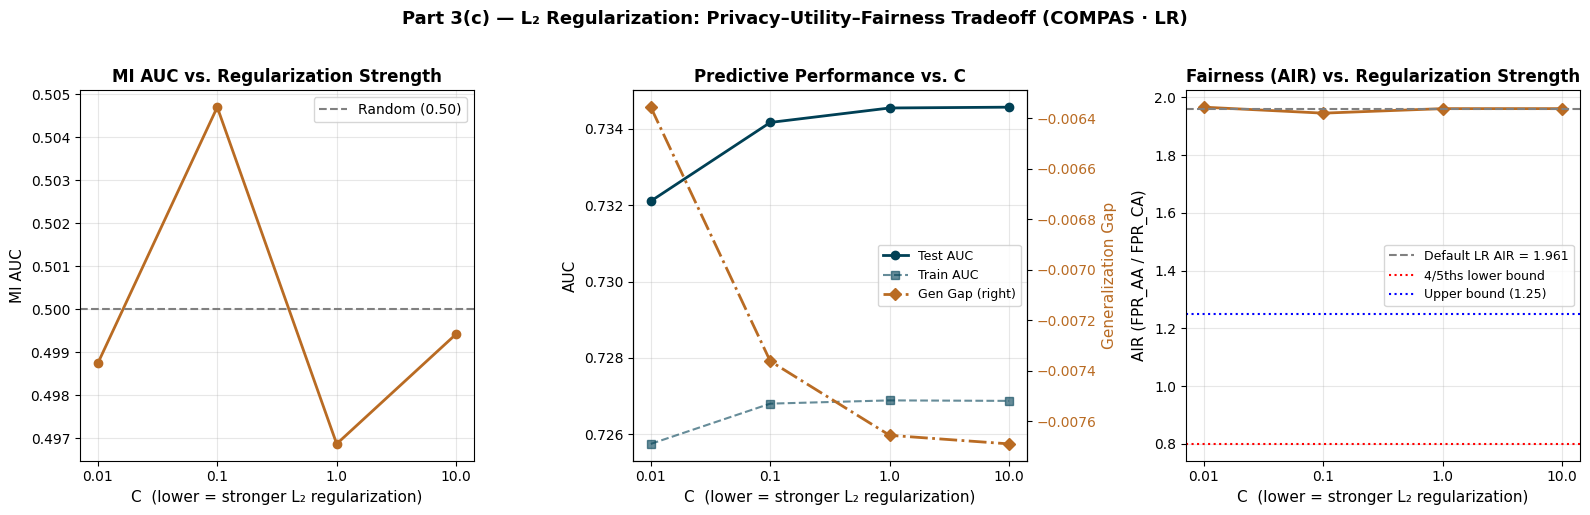

In [17]:
# ── Cell HW-9: (c) L₂ Regularization Sweep — MI AUC vs. C ───────────────────
#
# In sklearn LogisticRegression, C = 1 / regularization strength.
# Lower C → stronger L₂ penalty → smaller gen gap → lower MI AUC.
# But stronger regularization reduces capacity, potentially hurting AUC and AIR.

C_values   = [0.01, 0.1, 1.0, 10.0]
l2_records = []

print(f"{'C':>6}  {'Train AUC':>10} {'Test AUC':>10} {'Gen Gap':>10} "
      f"{'MI AUC':>10} {'AIR':>8} {'FPR_AA':>8} {'FPR_CA':>8}")
print("-" * 75)

for C in C_values:
    lr_reg   = LogisticRegression(C=C, penalty='l2', max_iter=1000).fit(Xs_tr, y_tr)

    # Shadow MI pipeline with matching regularization in shadow models
    s_tr_confs, s_te_confs = [], []
    sss_c = StratifiedShuffleSplit(n_splits=N_SHADOW, test_size=0.5, random_state=0)
    for tr_idx, te_idx in sss_c.split(Xs_tr, y_tr):
        sh = LogisticRegression(C=C, max_iter=1000).fit(Xs_tr[tr_idx], y_tr[tr_idx])
        s_tr_confs.append(sh.predict_proba(Xs_tr[tr_idx]).max(axis=1))
        s_te_confs.append(sh.predict_proba(Xs_tr[te_idx]).max(axis=1))

    mi_X_c = np.concatenate(s_tr_confs + s_te_confs).reshape(-1, 1)
    mi_y_c = np.concatenate(
        [np.ones(len(c))  for c in s_tr_confs] +
        [np.zeros(len(c)) for c in s_te_confs]
    )
    meta_c   = DecisionTreeClassifier(max_depth=6).fit(mi_X_c, mi_y_c)
    conf_tr_c = lr_reg.predict_proba(Xs_tr).max(axis=1).reshape(-1, 1)
    conf_te_c = lr_reg.predict_proba(Xs_te).max(axis=1).reshape(-1, 1)
    mi_scores_c = np.concatenate([
        meta_c.predict_proba(conf_tr_c)[:, 1],
        meta_c.predict_proba(conf_te_c)[:, 1]
    ])
    mi_labels_c = np.concatenate([np.ones(len(Xs_tr)), np.zeros(len(Xs_te))])
    mi_auc_c    = roc_auc_score(mi_labels_c, mi_scores_c)

    # Performance and fairness
    auc_tr_c = roc_auc_score(y_tr, lr_reg.predict_proba(Xs_tr)[:, 1])
    auc_te_c = roc_auc_score(y_te, lr_reg.predict_proba(Xs_te)[:, 1])
    gen_c    = auc_tr_c - auc_te_c
    pred_c   = (lr_reg.predict_proba(Xs_te)[:, 1] >= THR).astype(int)
    fpr_c    = fpr_by_group(y_te, pred_c, r_te)
    aa_c     = fpr_c.get('African-American', np.nan)
    ca_c     = fpr_c.get('Caucasian',        np.nan)
    air_c    = air(ca_c, aa_c)

    l2_records.append({
        'C': C, 'train_AUC': auc_tr_c, 'test_AUC': auc_te_c,
        'gen_gap': gen_c, 'MI_AUC': mi_auc_c,
        'AIR': air_c, 'FPR_AA': aa_c, 'FPR_CA': ca_c,
    })
    print(f"{C:>6.2f}  {auc_tr_c:>10.3f} {auc_te_c:>10.3f} {gen_c:>+10.3f} "
          f"{mi_auc_c:>10.3f} {air_c:>8.3f} {aa_c:>8.3f} {ca_c:>8.3f}")

df_l2 = pd.DataFrame(l2_records)

# ── Plot MI AUC vs. C ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
c_log    = np.log10(df_l2['C'])
c_labels = [str(c) for c in df_l2['C']]

# Panel 1: MI AUC vs. C
ax = axes[0]
ax.plot(c_log, df_l2['MI_AUC'], 'o-', color='#B96B23', lw=2)
ax.axhline(0.5, color='gray', ls='--', lw=1.5, label='Random (0.50)')
ax.set_xticks(c_log); ax.set_xticklabels(c_labels)
ax.set_xlabel('C  (lower = stronger L₂ regularization)', fontsize=11)
ax.set_ylabel('MI AUC', fontsize=11)
ax.set_title('MI AUC vs. Regularization Strength', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# Panel 2: Test AUC and Gen Gap vs. C
ax  = axes[1]
ax2 = ax.twinx()
ax.plot(c_log, df_l2['test_AUC'],  'o-',  color='#004055', lw=2, label='Test AUC')
ax.plot(c_log, df_l2['train_AUC'], 's--', color='#004055', lw=1.5, alpha=0.6,
        label='Train AUC')
ax2.plot(c_log, df_l2['gen_gap'], 'D-.', color='#B96B23', lw=2,
         label='Gen Gap (right)')
ax.set_xticks(c_log); ax.set_xticklabels(c_labels)
ax.set_xlabel('C  (lower = stronger L₂ regularization)', fontsize=11)
ax.set_ylabel('AUC', fontsize=11)
ax2.set_ylabel('Generalization Gap', fontsize=11, color='#B96B23')
ax2.tick_params(axis='y', labelcolor='#B96B23')
ax.set_title('Predictive Performance vs. C', fontsize=12, fontweight='bold')
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labs1 + labs2, fontsize=9)
ax.grid(alpha=0.3)

# Panel 3: AIR vs. C
ax = axes[2]
ax.plot(c_log, df_l2['AIR'], 'D-', color='#B96B23', lw=2)
ax.axhline(BASELINE_AIR, color='gray', ls='--', lw=1.5,
           label=f'Default LR AIR = {BASELINE_AIR:.3f}')
ax.axhline(0.80, color='red',  ls=':', lw=1.5, label='4/5ths lower bound')
ax.axhline(1.25, color='blue', ls=':', lw=1.5, label='Upper bound (1.25)')
ax.set_xticks(c_log); ax.set_xticklabels(c_labels)
ax.set_xlabel('C  (lower = stronger L₂ regularization)', fontsize=11)
ax.set_ylabel('AIR (FPR_AA / FPR_CA)', fontsize=11)
ax.set_title('Fairness (AIR) vs. Regularization Strength', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle(
    'Part 3(c) — L₂ Regularization: Privacy–Utility–Fairness Tradeoff (COMPAS · LR)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()


Gen gap predicts MI AUC?
Technically it would be YES (GBT has larger gap +0.080 and higher MI AUC 0.500 vs 0.497), but both are at random, and the tabular dataset doesn't overfit enough to produce exploitable confidence separation.

L₂ tradeoff
Regularization provides no meaningful privacy benefit here. MI AUC is already random at all C values. C = 1.0 is optimal: highest test AUC (0.735), stable AIR (1.961), MI AUC at random.

Part 4: Evidence Summary for Reflection

In [18]:
# ── Cell HW-10: Cross-Part Evidence Summary ──────────────────────────────────
#
# This cell assembles a concise evidence table from all three parts.
# Use these numbers directly in your written reflection below.

print("=" * 70)
print("PART 4 — CROSS-PART EVIDENCE SUMMARY")
print("=" * 70)

print("\n── Part 1: PGD AIR at required ε values ──")
print(df_pgd_hw[['epsilon', 'LR_AIR', 'GBT_AIR']].round(3).to_string(index=False))

print("\n── Part 2: Stealth zones ──")
for label, df_v in [('African-American', df_poison),
                     ('Caucasian',        df_poison_ca_target)]:
    s = df_v[(df_v['delta_AUC'] >= -0.02) &
             ((df_v['AIR'] < 0.80) | (df_v['AIR'] > 1.25))]
    if len(s):
        print(f"  Target={label}: stealth zone [{s['poison_rate'].min():.0%}, "
              f"{s['poison_rate'].max():.0%}]")
    else:
        print(f"  Target={label}: no stealth zone")

print("\n── Part 3: MI AUC and generalization gap ──")
print(f"  LR  — MI AUC: {mi_auc_lr:.3f}  |  Gen Gap: {gen_gap_lr:+.3f}")
print(f"  GBT — MI AUC: {mi_auc:.3f}  |  Gen Gap: {gen_gap_gbt:+.3f}")

print("\n── Part 3(c): L₂ sweep ──")
print(df_l2[['C', 'MI_AUC', 'test_AUC', 'AIR']].round(3).to_string(index=False))


PART 4 — CROSS-PART EVIDENCE SUMMARY

── Part 1: PGD AIR at required ε values ──
 epsilon  LR_AIR  GBT_AIR
    0.00   1.961    1.782
    0.25   1.535    1.782
    0.50   1.411    1.782
    1.00   1.106    1.782
    2.00   1.000    1.782

── Part 2: Stealth zones ──
  Target=African-American: stealth zone [0%, 30%]
  Target=Caucasian: stealth zone [0%, 30%]

── Part 3: MI AUC and generalization gap ──
  LR  — MI AUC: 0.497  |  Gen Gap: -0.008
  GBT — MI AUC: 0.500  |  Gen Gap: +0.080

── Part 3(c): L₂ sweep ──
    C  MI_AUC  test_AUC   AIR
 0.01   0.499     0.732 1.966
 0.10   0.505     0.734 1.946
 1.00   0.497     0.735 1.961
10.00   0.499     0.735 1.961
